 # **OCPTICAL CHARACTER RECOGNITION PROJECT - RECEIPT SCANNER** 🧾

In [ ]:
!pip install PyTesseract

**IMPORT LIBRARIES** ⬇

In [ ]:
from PIL import Image
import pytesseract
import cv2
from pytesseract import Output
from google.colab.patches import cv2_imshow
import re

**UPLOAD IMAGE** ⬇

In [ ]:
image_path = '/content/ocr_receipt_shana_gmeet.png'

In [ ]:
img = cv2.imread(image_path)

**OPEN CV PROCESSING** ⬇

In [ ]:
d = pytesseract.image_to_data(img,output_type=Output.DICT)
print(d)

{'level': [1, 2, 3, 4, 5, 4, 5, 5, 2, 3, 4, 5, 2, 3, 4, 5, 5, 2, 3, 4, 5, 5, 5, 2, 3, 4, 5, 5, 5, 4, 5, 5, 5, 4, 5, 5, 5, 4, 5, 5, 5, 3, 4, 5, 5, 5, 2, 3, 4, 5, 5, 4, 5, 5, 4, 5, 2, 3, 4, 5, 5, 5, 2, 3, 4, 5, 5, 4, 5, 5, 4, 5, 5, 5, 2, 3, 4, 5, 2, 3, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 5, 2, 3, 4, 5, 5, 5, 5, 5, 5, 2, 3, 4, 5, 2, 3, 4, 5, 4, 5, 4, 5, 4, 5, 5, 4, 5, 5, 2, 3, 4, 5, 4, 5, 4, 5], 'page_num': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'block_num': [0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 

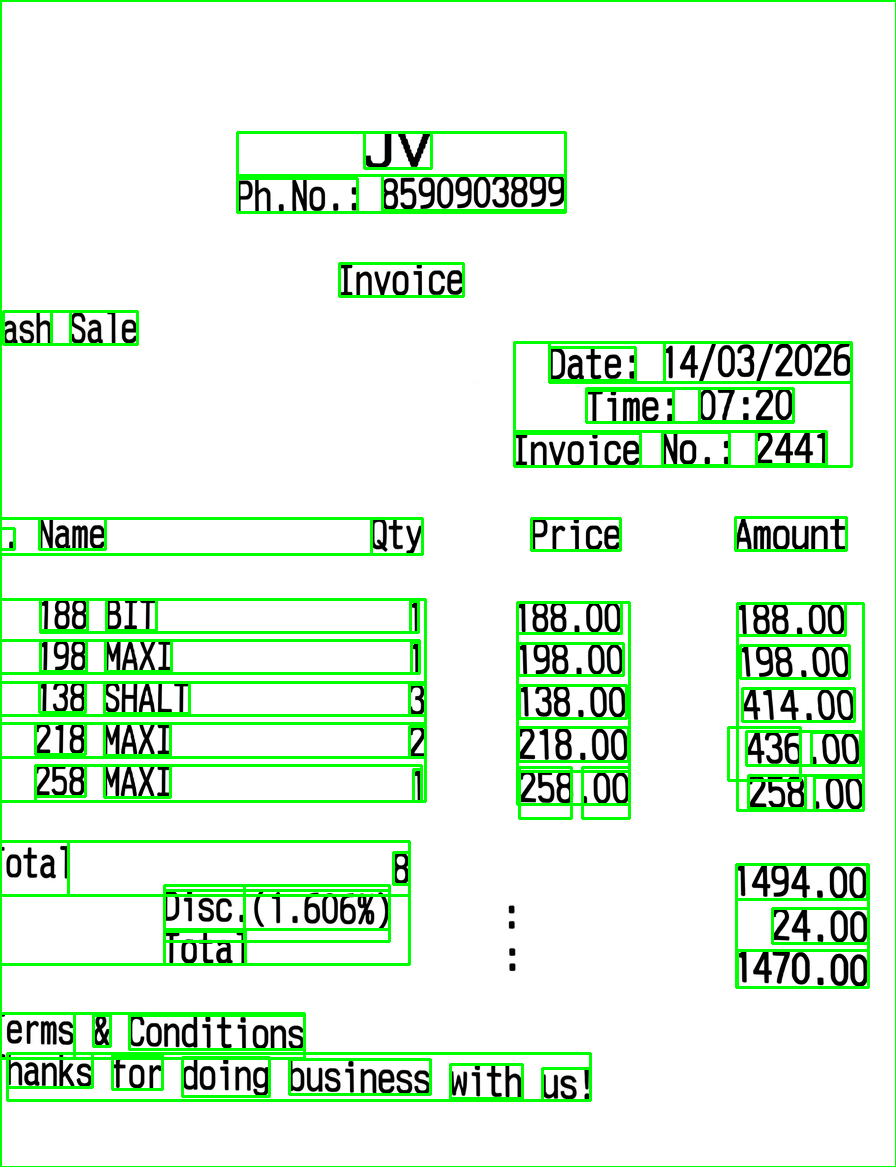

In [ ]:
for i in range(len(d['text'])):
  x,y,w,h = d['left'][i],d['top'][i],d['width'][i],d['height'][i]
  cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

cv2_imshow(img)

**EXTRACT RAW TEXT** ⬇

In [ ]:
extracted_text = pytesseract.image_to_string(img)
extracted_text

' \n\n \n\nJV\nPh. No. i B590903899\n\nDatei 14/03/2026\nTime i 07:20\nInvoice No. i 2441\n\nName Qty Price\n\n \n\nISS SHAL. —S~*~S~O\nQIGMAXI—S«S\n\n1494.00\n\n24.00\n1470.00\n\n \n\n \n\n \n\x0c'

**CLEANING USING REGEX** ⬇

In [ ]:
img_original = cv2.imread(image_path)
extracted_text = pytesseract.image_to_string(img_original)


**EXTRACT DATE**

CORRECTED DATE PATTERN FROM /d to \d ⬇

In [ ]:
date_pattern = r'\b\d{2}[/-]\d{2}[/-]\d{2,4}\b'
date = re.findall(date_pattern,extracted_text)

**EXTRACT AMOUNT** ⬇

In [ ]:
amount_pattern = r'\d+\.\d{2}'
amount = re.findall(amount_pattern,extracted_text)
total_amount = amount[-1] if amount else 'N/A'  # Added Check For Empty List

**EXTRACT STORE NAME** ⬇

In [ ]:
lines = extracted_text.splitlines()
store_name = lines[0].strip() if lines and lines[0].strip() else 'N/A'  # Added Check For Empty List And Empty String

### **FINAL OUTPUT** ✅

In [ ]:
print("Store Name :",store_name)
print("Date :",date)
print("Total Amount :",total_amount)

Store Name : JV
Date : ['14/03/2026']
Total Amount : 1470.00
